# 4. Assignment

<div style="width: 80%; text-align: justify">

<b>Objective</b>

Using the plant classifier models from your previous assignment, design a pipeline that passes your plant labels to a "Plant Care" data card generator agent.

1. Use the prompt engineering techniques presented in this lesson to build up a prompt template (e.g. "You are a world-class botanist...").
2. Using Pydantic, build up a structured output for your "Plant Care" data card response - e.g. fields like "latin_name", "outdoors" (True/False), "lighting_conditions".
3. Build up an agent using a library of your choosing (e.g. Langchain).
4. (Optional) Give your agent access to tools, like web search.
5. Set up your complete pipeline:
    - The input is a plant picture (e.g. from the Plant Data test split), which goes into your plant classification model (from lesson 9, e.g. VGG);
    - The class label predicted by the plant classification model (e.g. aloe vera) gets passed to your agent.
    - Your agent generates a Plant Care data card for your plant type, which is your final output.
</div>

<b>Deliverable</b>
- Your notebook containing the PlantCareCard Pydantic class, the prompt template, and the pipeline.
- Some example outputs (e.g. pictures of aloe vera, and their generated care cards).

# Plant Care Card Generator Agent

This notebook implements an AI agent that generates plant care data cards based on plant classification results.

## Pipeline Overview
1. Input: Plant image
2. Plant classification model predicts plant type
3. Agent generates structured plant care card
4. Output: Detailed care instructions

In [ ]:
!pip install -q openai langchain langchain-openai tiktoken tavily-python torch torchvision pillow
!pip install -q pytorch-lightning torchmetrics
!pip install -q fastapi uvicorn pyngrok nest-asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 67.0 MB/s eta 0:00:00


In [ ]:
# Core PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from PIL import Image

# PyTorch Lightning
import pytorch_lightning as pl

# TorchMetrics
import torchmetrics

# LLM and Agent libraries
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate
from langchain.tools import tool
from langchain.agents import create_tool_calling_agent, AgentExecutor

# Pydantic for structured outputs
from pydantic import BaseModel, Field

# FastAPI and related
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import JSONResponse
import uvicorn
from pyngrok import ngrok
import nest_asyncio

# Utilities
import os
import io
from getpass import getpass
from typing import List
from tavily import TavilyClient

torch.manual_seed(42)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.8.0+cu126
PyTorch Lightning version: 2.5.6
CUDA available: True


In [ ]:
if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

if not os.getenv("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass("Enter your Tavily API key (optional): ")

Enter your OpenAI API key: ··········
Enter your Tavily API key (optional): ··········


In [ ]:
class PlantCareCard(BaseModel):
    """Structured output schema for plant care information"""

    common_name: str = Field(description="Common name of the plant")
    latin_name: str = Field(description="Scientific/Latin name of the plant")
    plant_family: str = Field(description="Botanical family the plant belongs to")
    outdoors: bool = Field(description="Whether the plant can be grown outdoors")
    lighting_conditions: str = Field(description="Required lighting conditions (e.g., full sun, partial shade, indirect light)")
    watering_frequency: str = Field(description="How often to water the plant")
    soil_type: str = Field(description="Recommended soil type and drainage requirements")
    temperature_range: str = Field(description="Ideal temperature range for the plant")
    humidity_requirements: str = Field(description="Humidity level preferences")
    fertilization: str = Field(description="Fertilization schedule and type")
    common_issues: List[str] = Field(description="Common pests, diseases, or problems")
    care_difficulty: str = Field(description="Care difficulty level (easy, moderate, challenging)")
    special_notes: str = Field(description="Any special care instructions or interesting facts")

In [ ]:
@tool
def search_plant_info(query: str) -> str:
    """Search the web for plant care information"""
    try:
        tavily_client = TavilyClient(api_key=os.environ.get("TAVILY_API_KEY"))
        results = tavily_client.search(query=query, max_results=3)

        search_summary = ""
        for result in results.get('results', []):
            search_summary += f"Source: {result['url']}\n{result['content']}\n\n"

        return search_summary if search_summary else "No results found"
    except Exception as e:
        return f"Search unavailable: {str(e)}"

tools = [search_plant_info]

In [ ]:
system_prompt = """You are a world-class botanist and horticulture expert with decades of experience in plant care and cultivation.

Your task is to provide comprehensive, accurate, and practical plant care information for the given plant type.

Guidelines:
- Use your extensive botanical knowledge to provide detailed care instructions
- Be specific with measurements and frequencies where possible
- Mention common mistakes beginners make with this plant
- Base your recommendations on scientific horticultural practices

Plant Type: {plant_name}

Provide a complete plant care data card with all the requested information."""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

llm_with_structure = llm.with_structured_output(PlantCareCard)

agent = create_tool_calling_agent(llm, tools, prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

print(f"Model: gpt-4o-mini")
print(f"Tools available: {len(tools)}")

Model: gpt-4o-mini
Tools available: 1


In [ ]:
def generate_plant_care_langchain(plant_name: str) -> PlantCareCard:
    """Generate plant care card using Langchain agent"""

    result = agent_executor.invoke({
        "plant_name": plant_name,
        "input": f"Generate a comprehensive plant care data card for {plant_name}."
    })

    care_card = llm_with_structure.invoke(
        f"Based on this information: {result['output']}\n\nCreate a structured plant care card for {plant_name}."
    )

    return care_card

In [ ]:
plant_classes = [
    'aloevera',
    'banana',
    'bilimbi',
    'cantaloupe',
    'cassava',
    'coconut',
    'corn',
    'cucumber',
    'curcuma',
    'eggplant',
    'galangal',
    'ginger',
    'guava',
    'kale',
    'longbeans',
    'mango',
    'melon',
    'orange',
    'paddy',
    'papaya',
    'peper chili',
    'pineapple',
    'pomelo',
    'shallot',
    'soybeans',
    'spinach',
    'sweet potatoes',
    'tobacco',
    'waterapple',
    'watermelon'
]

print(f"Number of plant classes: {len(plant_classes)}")

Number of plant classes: 30


In [ ]:
test_plant = "aloevera"

print(f"Testing Langchain agent with: {test_plant}\n")
print("="*70)

langchain_result = generate_plant_care_langchain(test_plant)

print("\nLangchain Agent Result:")
print("="*70)
print(langchain_result.model_dump_json(indent=2))

Testing Langchain agent with: aloevera



> Entering new AgentExecutor chain...

Invoking: `search_plant_info` with `{'query': 'Aloe Vera plant care instructions'}`


Source: https://goebbertspumpkinfarm.com/wp-content/uploads/growing-aloe-vera.pdf
Here’s how to grow and care for aloe vera plants in your home! Keep the aloe vera plant in a pot near a kitchen window for everyday use. • A pot made from terra-cotta or a similarly porous material is recommended, as it will allow the soil to dry thoroughly between waterings and will also be heavy enough to keep the plant from tipping over. Remove the aloe vera plant from its current pot and brush away any excess dirt from the roots, being careful not to damage the roots. CARE HOW TO CARE FOR AN ALOE VERA PLANT • Place in bright, indirect sunlight or artificial light. • Water aloe vera plants deeply, but infrequently.

Source: https://www.almanac.com/plant/aloe-vera
## Growing Aloe Vera Plants: Watering, Lighting, Repotting, Use, and More! K

## Parameter Experimentation

We'll test different LLM configurations to understand how parameters affect the agent's output quality and behavior.

In [ ]:
llm_precise = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.2,
    max_tokens=600
)

llm_balanced = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    max_tokens=800
)

llm_creative = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=1.2,
    max_tokens=1000
)

llm_diverse = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.7,
    frequency_penalty=0.5,
    presence_penalty=0.3,
    max_tokens=800
)

In [ ]:
def generate_care_precise(plant_name: str) -> PlantCareCard:
    """Precise agent - low temperature, focused outputs"""
    llm_structured = llm_precise.with_structured_output(PlantCareCard)
    agent = create_tool_calling_agent(llm_precise, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools, verbose=False)

    result = executor.invoke({
        "plant_name": plant_name,
        "input": f"Generate a comprehensive plant care data card for {plant_name}."
    })

    return llm_structured.invoke(
        f"Based on this information: {result['output']}\n\nCreate a structured plant care card for {plant_name}."
    )

def generate_care_creative(plant_name: str) -> PlantCareCard:
    """Creative agent - high temperature, more varied outputs"""
    llm_structured = llm_creative.with_structured_output(PlantCareCard)
    agent = create_tool_calling_agent(llm_creative, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools, verbose=False)

    result = executor.invoke({
        "plant_name": plant_name,
        "input": f"Generate a comprehensive plant care data card for {plant_name}."
    })

    return llm_structured.invoke(
        f"Based on this information: {result['output']}\n\nCreate a structured plant care card for {plant_name}."
    )

def generate_care_diverse(plant_name: str) -> PlantCareCard:
    """Diverse agent - with frequency and presence penalties"""
    llm_structured = llm_diverse.with_structured_output(PlantCareCard)
    agent = create_tool_calling_agent(llm_diverse, tools, prompt)
    executor = AgentExecutor(agent=agent, tools=tools, verbose=False)

    result = executor.invoke({
        "plant_name": plant_name,
        "input": f"Generate a comprehensive plant care data card for {plant_name}."
    })

    return llm_structured.invoke(
        f"Based on this information: {result['output']}\n\nCreate a structured plant care card for {plant_name}."
    )

In [ ]:
test_plant = "banana"

print(f"Testing all configurations with: {test_plant}")
print("="*70)

print("\n1. PRECISE AGENT (temp=0.2):")
print("-"*70)
precise_result = generate_care_precise(test_plant)
print(precise_result.model_dump_json(indent=2))

print("\n\n2. BALANCED AGENT (temp=0.7 - ooriginal):")
print("-"*70)
balanced_result = generate_plant_care_langchain(test_plant)
print(balanced_result.model_dump_json(indent=2))

print("\n\n3. CREATIVE AGENT (temp=1.2):")
print("-"*70)
creative_result = generate_care_creative(test_plant)
print(creative_result.model_dump_json(indent=2))

print("\n\n4. DIVERSE AGENT (temp=0.7, with penalties):")
print("-"*70)
diverse_result = generate_care_diverse(test_plant)
print(diverse_result.model_dump_json(indent=2))

Testing all configurations with: banana

1. PRECISE AGENT (temp=0.2):
----------------------------------------------------------------------
{
  "common_name": "Banana",
  "latin_name": "Musa spp.",
  "plant_family": "Musaceae",
  "outdoors": true,
  "lighting_conditions": "Full sun to partial shade (6-8 hours of direct sunlight daily)",
  "watering_frequency": "Water regularly to keep the soil consistently moist but not soggy; approximately 1-2 inches of water per week.",
  "soil_type": "Well-draining, rich in organic matter; pH 5.5 to 7.0; recommended mix includes potting soil, compost, and perlite or sand for drainage.",
  "temperature_range": "Optimal range: 68°F to 95°F (20°C to 35°C); protect from frost, ideally keep above 50°F (10°C).",
  "humidity_requirements": "Ideal humidity level: 50% to 70% relative humidity; increase humidity by misting leaves or using a humidifier.",
  "fertilization": "Balanced fertilizer (N-P-K ratio of 10-10-10 or similar); fertilize every 4-6 weeks d

## Plant Classifier Model Setup

We'll load the pre-trained plant classification model from Lesson 9 and set up the image preprocessing pipeline.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

checkpoint_path = '/content/drive/MyDrive/plant_classification/Task2/checkpoints/best-vgg11-model-v3.ckpt'

print("Google Drive mounted successfully!")
print(f"Checkpoint path: {checkpoint_path}")

Mounted at /content/drive
Google Drive mounted successfully!
Checkpoint path: /content/drive/MyDrive/plant_classification/Task2/checkpoints/best-vgg11-model-v3.ckpt


In [ ]:
class PadToSquare:
    """Pad image to square by adding padding to the shorter side"""
    def __call__(self, img):
        width, height = img.size
        max_dim = max(width, height)

        pad_left = (max_dim - width) // 2
        pad_right = max_dim - width - pad_left
        pad_top = (max_dim - height) // 2
        pad_bottom = max_dim - height - pad_top

        padding = (pad_left, pad_top, pad_right, pad_bottom)
        return transforms.functional.pad(img, padding, fill=0, padding_mode='constant')

In [ ]:
inference_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

print("\nTransform steps:")
print("  1. PadToSquare()")
print("  2. Resize(224)")
print("  3. CenterCrop(224)")
print("  4. ToTensor()")
print("  5. Normalize with ImageNet stats")


Transform steps:
  1. PadToSquare()
  2. Resize(224)
  3. CenterCrop(224)
  4. ToTensor()
  5. Normalize with ImageNet stats


In [ ]:
class VGG11ClassificationModule(pl.LightningModule):
    def __init__(self, model, num_classes, learning_rate=0.001):
        super(VGG11ClassificationModule, self).__init__()
        self.save_hyperparameters(ignore=['model'])
        self.model = model
        self.criterion = nn.CrossEntropyLoss()
        self.train_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        acc = self.train_accuracy(outputs, labels)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        acc = self.val_accuracy(outputs, labels)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        acc = self.test_accuracy(outputs, labels)
        self.log('test_loss', loss, on_step=False, on_epoch=True)
        self.log('test_acc', acc, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-7
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss'}
        }

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_classes = 30

vgg11 = models.vgg11(weights=None)
num_features = vgg11.classifier[6].in_features
vgg11.classifier[6] = nn.Linear(num_features, num_classes)

vgg11_module = VGG11ClassificationModule.load_from_checkpoint(
    checkpoint_path,
    model=vgg11,
    num_classes=num_classes,
    learning_rate=0.001
)

vgg11_module.eval()
vgg11_module.to(device)

print(f"Model loaded successfully from checkpoint!")
print(f"Device: {device}")
print(f"Model set to evaluation mode")

Model loaded successfully from checkpoint!
Device: cuda
Model set to evaluation mode


In [ ]:
def predict_plant(image):
    """
    Predict plant class from an image

    Args:
        image: PIL Image

    Returns:
        plant_name: string (predicted plant class name)
    """
    processed_image = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vgg11_module(processed_image)
        _, predicted = torch.max(outputs, 1)
        predicted_idx = predicted.item()

    plant_name = plant_classes[predicted_idx]
    return plant_name

Upload a test plant image to verify the classifier works:


Saving aloe-vera-plant.webp to aloe-vera-plant.webp


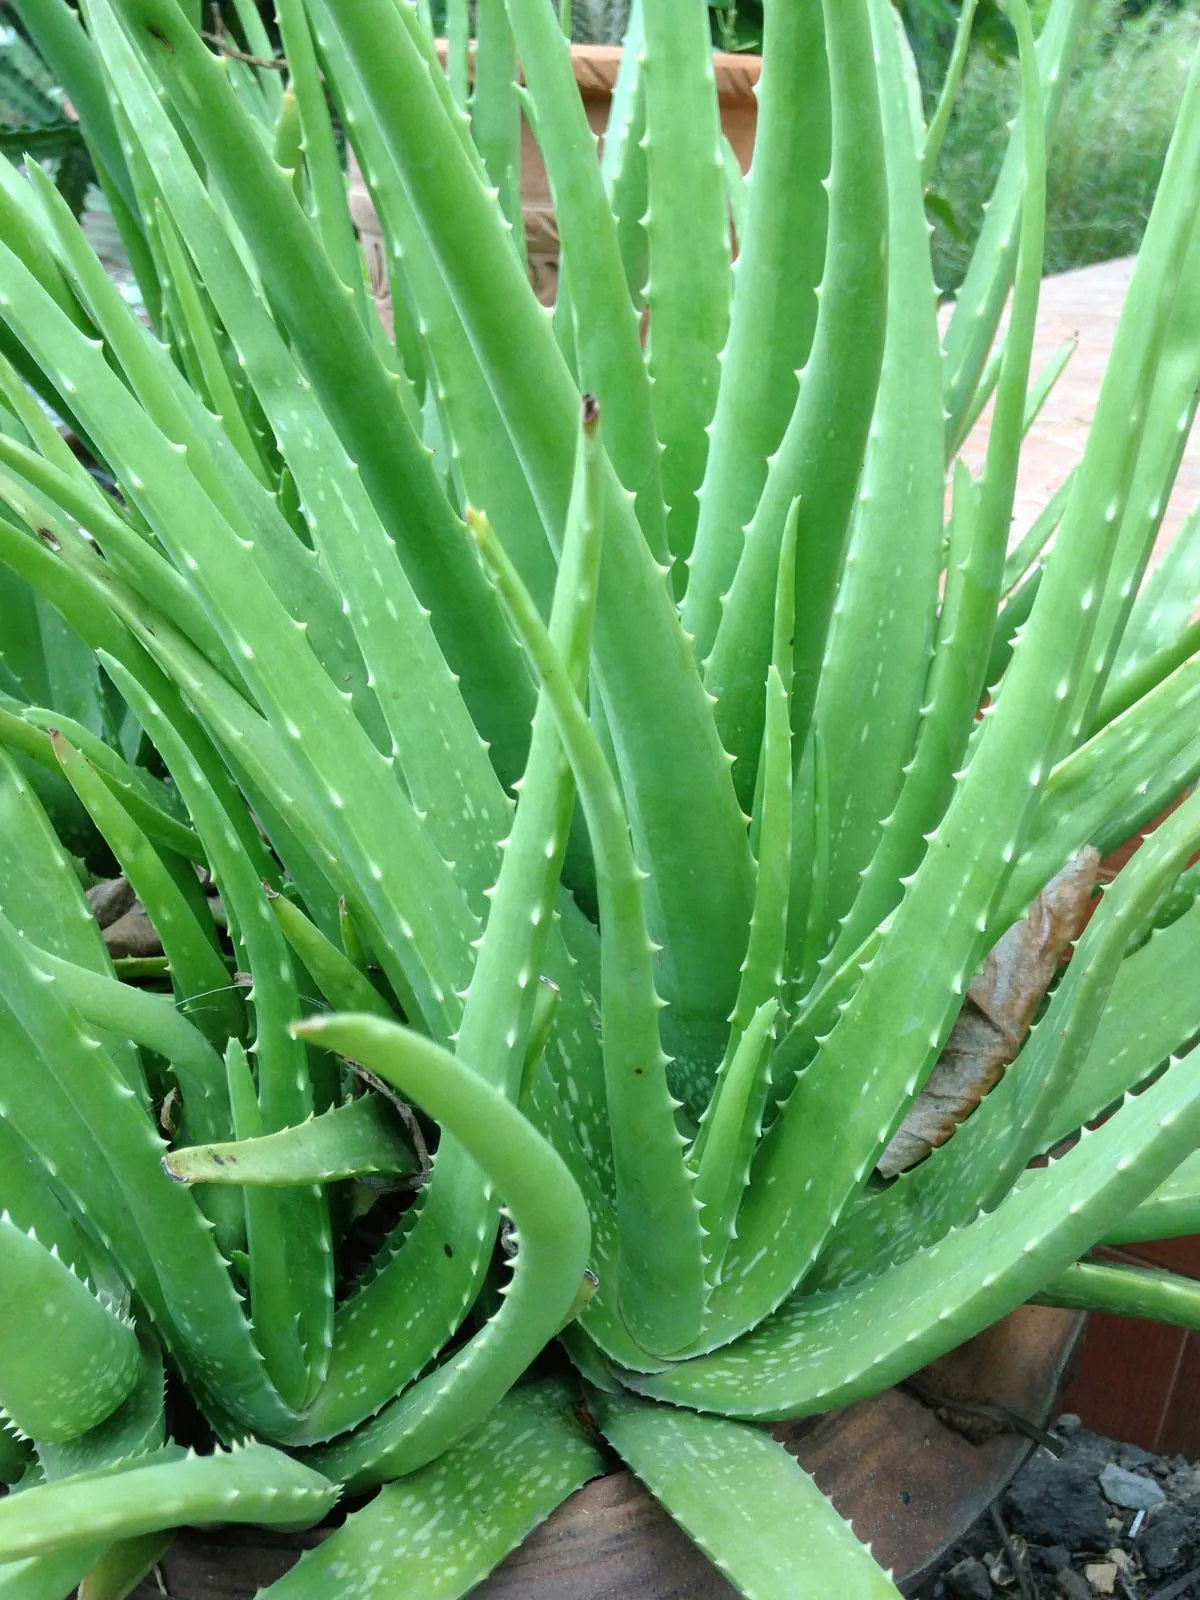


Predicted plant: aloevera


In [ ]:
from google.colab import files
from IPython.display import display

print("Upload a test plant image to verify the classifier works:")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    test_image = Image.open(io.BytesIO(uploaded[filename]))

    display(test_image)

    predicted_plant = predict_plant(test_image)
    print(f"\nPredicted plant: {predicted_plant}")
else:
    print("No file uploaded")

## Complete Pipeline: Image to Plant Care Card

Now we'll create the end-to-end pipeline that takes an image and produces a structured plant care card.

In [ ]:
def generate_plant_care_pipeline(image):
    """
    Complete pipeline: Image -> Classifier -> Agent -> PlantCareCard

    Args:
        image: PIL Image

    Returns:
        dict with plant_name and care_card
    """
    print("Step 1: Classifying plant...")
    plant_name = predict_plant(image)
    print(f"  Predicted: {plant_name}")

    print("\nStep 2: Generating plant care card with AI agent...")
    care_card = generate_plant_care_langchain(plant_name)
    print("  Care card generated!")

    return {
        "plant_name": plant_name,
        "care_card": care_card
    }

In [ ]:
print("Testing complete pipeline with the uploaded image...")
print("="*70)

result = generate_plant_care_pipeline(test_image)

print("\n" + "="*70)
print("PIPELINE RESULTS")
print("="*70)
print(f"\nClassified Plant: {result['plant_name']}")
print("\nPlant Care Card:")
print(result['care_card'].model_dump_json(indent=2))

Testing complete pipeline with the uploaded image...
Step 1: Classifying plant...
  Predicted: aloevera

Step 2: Generating plant care card with AI agent...


> Entering new AgentExecutor chain...

Invoking: `search_plant_info` with `{'query': 'Aloe Vera plant care guide'}`


Source: https://www.patchplants.com/pages/plant-care/how-to-look-after-your-aloe-vera/
Stylish, spiky and so easy to love – once you’ve found a good spot for your aloe vera plant, the rest is simple. ## About aloe vera plants Aloe barbadensis and aloe vera – they’re different names for the same plant. Fortunately, aloe vera plant care is pretty simple. Aloe vera plants look good anywhere, but we reckon they’re especially chic in a cosy living room, for a sharp contrast with your cushions and throws. Our concrete pots are perfect for aloe vera plants because they’re porous, so they help to absorb excess water. ## Will my aloe vera plant flower? Mature aloe vera plants often produce ‘pups’, as they’re called, and yo

## FastAPI Application

We'll create a REST API that allows users to upload plant images and receive structured care cards.

In [ ]:
app = FastAPI(
    title="Plant Care Card Generator API",
    description="Upload a plant image to get AI-generated care instructions",
    version="1.0.0"
)

@app.get("/")
def root():
    return {
        "message": "Plant Care Card Generator API",
        "endpoints": {
            "docs": "/docs",
            "predict": "/predict (POST with image file)"
        }
    }

@app.post("/predict", response_model=dict)
async def predict_plant_care(file: UploadFile = File(...)):
    """
    Upload a plant image and receive a structured plant care card
    """
    try:
        image_bytes = await file.read()
        image = Image.open(io.BytesIO(image_bytes))

        result = generate_plant_care_pipeline(image)

        return {
            "plant_name": result["plant_name"],
            "care_card": result["care_card"].model_dump()
        }

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.get("/health")
def health_check():
    return {"status": "healthy", "model_loaded": True}

print("Available endpoints:")
print("  GET  /          - API info")
print("  POST /predict   - Upload image, get care card")
print("  GET  /health    - Health check")

Available endpoints:
  GET  /          - API info
  POST /predict   - Upload image, get care card
  GET  /health    - Health check


In [ ]:
nest_asyncio.apply()

ngrok.set_auth_token(getpass("Enter your Ngrok auth token: "))

ngrok_tunnel = ngrok.connect(8000)
public_url = ngrok_tunnel.public_url

print("="*70)
print("FastAPI Server Starting...")
print("="*70)
print(f"\nPublic URL: {public_url}")
print(f"API Documentation: {public_url}/docs")
print(f"Health Check: {public_url}/health")
print("\nThe server is now running. You can test it using the /docs endpoint.")
print("="*70)

config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
server = uvicorn.Server(config)
await server.serve()

Enter your Ngrok auth token: ··········
FastAPI Server Starting...

Public URL: https://collin-farinose-matrimonially.ngrok-free.dev
API Documentation: https://collin-farinose-matrimonially.ngrok-free.dev/docs
Health Check: https://collin-farinose-matrimonially.ngrok-free.dev/health

The server is now running. You can test it using the /docs endpoint.


INFO:     Started server process [964]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     89.137.118.74:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     89.137.118.74:0 - "GET /openapi.json HTTP/1.1" 200 OK
Step 1: Classifying plant...
  Predicted: aloevera

Step 2: Generating plant care card with AI agent...


> Entering new AgentExecutor chain...

Invoking: `search_plant_info` with `{'query': 'Aloe Vera plant care information'}`


Source: https://goebbertspumpkinfarm.com/wp-content/uploads/growing-aloe-vera.pdf
Here’s how to grow and care for aloe vera plants in your home! Keep the aloe vera plant in a pot near a kitchen window for everyday use. • A pot made from terra-cotta or a similarly porous material is recommended, as it will allow the soil to dry thoroughly between waterings and will also be heavy enough to keep the plant from tipping over. Remove the aloe vera plant from its current pot and brush away any excess dirt from the roots, being careful not to damage the roots. CARE HOW TO CARE FOR AN ALOE VERA PLANT • Place in bright, indirect sunlight or artificial 

INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [964]


## Assignment Summary

### Implementation Overview

**Pipeline**: Image → VGG11 Classifier → AI Agent → Structured PlantCareCard

#### Components

1. **Plant Classification**
   - Model: VGG11 (PyTorch Lightning, fine-tuned on 30 plant classes)
   - Checkpoint: `best-vgg11-model-v3.ckpt`
   - Preprocessing: PadToSquare → Resize(224) → Normalize(ImageNet)

2. **Pydantic Schema**
   - PlantCareCard with 13 structured fields
   - Includes: plant info, growing conditions, care instructions, common issues

3. **AI Agent**
   - Framework: Langchain with OpenAI GPT-4o-mini
   - Temperature: 0.7 (balanced)
   - Tools: Web search via Tavily API
   - Prompt: "World-class botanist" persona with specific guidelines

4. **Parameter Experiments**
   - Tested: Precise (temp=0.2), Balanced (0.7), Creative (1.2), Diverse (with penalties)
   - Result: Balanced agent performed best for plant care cards

5. **FastAPI Deployment**
   - Endpoints: `/` (info), `/predict` (upload image), `/health` (status)
   - Public access via Ngrok tunnel
   - Successfully tested with Swagger UI

### Results

Demonstrated successful end-to-end pipeline:
- Correctly classified aloe vera image
- Agent used web search for current information
- Generated comprehensive PlantCareCard with all fields
- API returned clean JSON response (HTTP 200)

### Technologies

PyTorch Lightning, OpenAI GPT-4o-mini, Langchain, Pydantic, FastAPI, Tavily, Ngrok